# Lab 4: DataFrames, Data Visualization, and Functions

Welcome to Lab 4! This lab covers DataFrame manipulations, making visualizations, and defining functions. You should complete this entire lab so that all tests pass.

You can find additional help on these topics in the pandas notes on [functions](https://notes.dsc10.com/01_getting_started/functions-defining.html) and [Chapter 7](https://inferentialthinking.com/chapters/07/Visualization.html) of the CIT textbook.

**Please do not use `for`-loops for any questions in this lab.** If you don't know what a `for`-loop is, don't worry - we haven't covered them yet. But if you do know what they are and are wondering why it's not OK to use them, it is because loops in Python are slow, and looping over arrays and DataFrames should usually be avoided.

First, set up the tests and imports by running the cell below.


In [1]:
in_colab = "google.colab" in str(get_ipython())
if in_colab:
    !pip install otter-grader==6.1.6

from pathlib import Path
import numpy as np
np.set_printoptions(legacy='1.21')

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-colorblind')
plt.rcParams['figure.figsize'] = (10, 5)

import pandas as pd

path = 'labs/lab04/build/student'
if in_colab:
    import shutil
    import zipfile

    assets = ['data', 'tests', 'images']
    missing_assets = [asset for asset in assets if not Path(asset).exists()]
    if missing_assets:
        !wget -q -O /content/course.zip https://github.com/dsc-courses/cosmos-ml-cluster-2026/archive/refs/heads/main.zip
        with zipfile.ZipFile('/content/course.zip') as course_zip:
            for asset in missing_assets:
                archive_prefix = f"cosmos-ml-cluster-2026-main/{path}/{asset}/"
                members = [name for name in course_zip.namelist() if name.startswith(archive_prefix)]
                if members:
                    course_zip.extractall('/content/course-assets', members)
                    source_path = Path('/content/course-assets') / archive_prefix
                    if source_path.exists():
                        shutil.copytree(source_path, asset, dirs_exist_ok=True)

import otter
grader = otter.Notebook()


## 1. ArtPower Events 🎨🎺💃

<center><img src="images/artpower.jpg" width=600/></center>

[ArtPower](https://artpower.ucsd.edu/) is a UC San Diego performing arts initiative that advertises events throughout the year. ArtPower's self-described mission is to "present performing arts that engage, energize, and transform the diverse cultural life of the university and San Diego." ArtPower events are open to the general public, and they encompass all sorts of performing arts, such as music, dance, and theatre.

In this question, we'll work with a dataset of upcoming ArtPower events in the 2024-25 season. This dataset was collected using a [web scraper](https://github.com/AustinFlippo/UCSD_Events_Scraper) that gathered information from the [ArtPower Events website](https://artpower.ucsd.edu/events/) and stored it in a DataFrame. This DataFrame, `artpower`, is provided below, and it contains the following information for each event.

|Column|Description|
|------|-----------|
|`'Event Name'`|The name of the event|
|`'Category'`|The type of event|
|`'Description'`|A brief summary of the event|
|`'Link'`|The link to the event webpage|
|`'Price'`|A breakdown of the pricing for different groups of people|
|`'Date'`|Day, month, and year of the event|
|`'Time'`|The day of the week and the time of the event|
|`'Location'`|Location of the event (often on campus, but not always)|
|`'Latitude'`|The latitude for the event's location|
|`'Longitude'`|The longitude for the event's location|


In [2]:
artpower = pd.read_csv('data/artpower.csv')
artpower

,Event Name,Category,Description,Link,Price,Date,Time,Location,Latitude,Longitude
0,An Evening with Fran Lebowitz,Speaker,“Fran Lebowitz’s trademark is the sneer; she d...,https://artpower.ucsd.edu/event/fran-lebowitz/,"['Reserved Seating: $52.50–78.90', 'UCSD Stud...",23-Jan-25,THU 7:30 pm,Balboa Theatre,32.714323,-117.161348
1,H.Sinno,Indie-Pop,Poems of Consumption turns Amazon customer rev...,https://artpower.ucsd.edu/event/h-sinno/,"['General Admission: $32', 'UCSD Student: Fr...",24-Jan-25,FRI 7:30 pm,Mandeville Auditorium,32.877742,-117.239442
2,Isaiah Collier: The World Is On Fire,Jazz,"Chicago/Brooklyn-based multi-instrumentalist, ...",https://artpower.ucsd.edu/event/isaiah-collier/,"['General Admission: $25', 'UCSD Student: Li...",4-Feb-25,TUE 8 pm,"The Loft, La Jolla",32.879464,-117.235911
3,Alfredo Rodríguez Quintet,Jazz,GRAMMY–nominated Cuban pianist Alfredo Rodrígu...,https://artpower.ucsd.edu/event/alfredo-rodrig...,"['General Admission: $35', 'UCSD Student: Li...",6-Feb-25,THU 7:30 pm,Mandeville Auditorium,32.877742,-117.239442
4,Ira Glass: Seven Things I've Learned,Speaker,“It's hard to make something that's interestin...,https://artpower.ucsd.edu/event/ira-glass/,"['Reserved Seating: $52.50–78.90', 'UCSD Stud...",8-Feb-25,SAT 7:30 pm,Balboa Theatre,32.714323,-117.161348
5,Harlem Quartet | Echoes of Inspiration,Chamber Music,“One of the greatest string quartets I have ev...,https://artpower.ucsd.edu/event/harlem-quartet...,"['Reserved Seating: Tickets start at $40', 'U...",14-Feb-25,FRI 7:30 pm,Department of Music's Conrad Prebys Concert Hall,32.878244,-117.234525
6,Dog Man The Musical,Family,“A howling good time. This show is perfect for...,https://artpower.ucsd.edu/event/dog-man-the-mu...,['Reserved Seating: Starts at $37.90'],15-Feb-25,SAT 11 am,Balboa Theatre,32.714323,-117.161348
7,Dog Man The Musical,Family,“A howling good time. This show is perfect for...,https://artpower.ucsd.edu/event/dog-man-the-mu...,['Reserved Seating: Starts at $37.90'],15-Feb-25,SAT 3 pm,Balboa Theatre,32.714323,-117.161348
8,Caroline Shaw & Sō Percussion featuring Ringdown,Chamber Music*,"For 20 years and counting, Sō Percussion has r...",https://artpower.ucsd.edu/event/caroline-shaw-...,"['General Admission: $40', 'UCSD Student: Li...",18-Feb-25,TUE 7:30 pm,Mandeville Auditorium,32.877742,-117.239442
9,Cesária Évora Orchestra,Global Music,A Tribute to the Barefoot Diva Tour The Cesári...,https://artpower.ucsd.edu/event/cesaria-evora-...,"['General Admission: $35', 'UCSD Student: Li...",25-Feb-25,TUE 7:30 pm,Price Center East Ballroom,32.879244,-117.231125


Let's start by exploring the `'Event Name'` column using the `describe()` method.

In [3]:
artpower.get('Event Name').describe()

count                      24
unique                     23
top       Dog Man The Musical
freq                        2
Name: Event Name, dtype: object

**Question 1.1.** From the output above, we see that there are 24 event names, but only 23 of them are unique. This means that there are two events with the same name in `artpower`. Find the name of the event that is duplicated and store the result in `same_name` below.

***Hint:*** Can you organize events so that events with the same name wind up together?

In [4]:
same_name = artpower.groupby('Event Name').count().sort_values(by='Link', ascending=False).index[0] # SOLUTION
same_name

'Dog Man The Musical'

In [5]:
bool(isinstance(same_name, str))

True

In [6]:
bool(same_name == 'Dog Man The Musical')

True

**Question 1.2.** Are these actually two different events? Or is there an error in the data whereby we actually have two rows corresponding to the same event at the same time and place? To answer this question, make a new DataFrame, `same_name_events`, which should have the same columns as `artpower`, but only the two rows whose `'Event Name'` is `same_name`, as you found in the previous question. Look to see if there are any differences between the two rows!

In [7]:
same_name_events = artpower[artpower.get('Event Name') == same_name] # SOLUTION
same_name_events

,Event Name,Category,Description,Link,Price,Date,Time,Location,Latitude,Longitude
6,Dog Man The Musical,Family,“A howling good time. This show is perfect for...,https://artpower.ucsd.edu/event/dog-man-the-mu...,['Reserved Seating: Starts at $37.90'],15-Feb-25,SAT 11 am,Balboa Theatre,32.714323,-117.161348
7,Dog Man The Musical,Family,“A howling good time. This show is perfect for...,https://artpower.ucsd.edu/event/dog-man-the-mu...,['Reserved Seating: Starts at $37.90'],15-Feb-25,SAT 3 pm,Balboa Theatre,32.714323,-117.161348


In [8]:
bool(isinstance(same_name_events, pd.DataFrame))

True

In [9]:
bool(same_name_events.shape == (2, 10))

True

In [10]:
bool((same_name_events.iloc[0] == same_name_events.iloc[1]).sum() == 7)

True

Next, let's look at the different event `'Category'` values that appear in the `artpower` DataFrame. You may notice that some events have a `'Category'` of `'Chamber Music'`, while others have a `'Category'` of `'Chamber Music*'`. 

In [11]:
artpower.get('Category').unique()

<StringArray>
[        'Speaker',       'Indie-Pop',            'Jazz',   'Chamber Music',
          'Family',  'Chamber Music*',    'Global Music', 'American Routes',
           'Dance',   'Special Event']
Length: 10, dtype: str

Why the asterisk, you ask? Great question! Here is ArtPower's explanation:

>**ASTERISK\***
>When you see this symbol\*, it indicates artists that are pushing the boundaries, often across genres.

**Question 1.3.** Then create a DataFrame called `chamber_music` that contains all the rows of `artpower` for events where the `'Category'` is `'Chamber Music'`, and all the rows for events where the `'Category'` is `'Chamber Music*'`, but no additional rows. 

In [12]:
chamber_music = artpower[(artpower.get('Category') == 'Chamber Music')|(artpower.get('Category') == 'Chamber Music*')] # SOLUTION
chamber_music

,Event Name,Category,Description,Link,Price,Date,Time,Location,Latitude,Longitude
5,Harlem Quartet | Echoes of Inspiration,Chamber Music,“One of the greatest string quartets I have ev...,https://artpower.ucsd.edu/event/harlem-quartet...,"['Reserved Seating: Tickets start at $40', 'U...",14-Feb-25,FRI 7:30 pm,Department of Music's Conrad Prebys Concert Hall,32.878244,-117.234525
8,Caroline Shaw & Sō Percussion featuring Ringdown,Chamber Music*,"For 20 years and counting, Sō Percussion has r...",https://artpower.ucsd.edu/event/caroline-shaw-...,"['General Admission: $40', 'UCSD Student: Li...",18-Feb-25,TUE 7:30 pm,Mandeville Auditorium,32.877742,-117.239442
10,Brentano String Quartet,Chamber Music,"With a career spanning over three decades, the...",https://artpower.ucsd.edu/event/brentano-strin...,"['Reserved Seating: Tickets start at $40', 'U...",28-Feb-25,FRI 7:30 pm,Department of Music's Conrad Prebys Concert Hall,32.878244,-117.234525
18,Meta4,Chamber Music,"Founded in 2001, Meta4 is one of Finland’s mos...",https://artpower.ucsd.edu/event/meta4/,"['Reserved Seating: Tickets start at $40', 'U...",25-Apr-25,FRI 7:30 pm,Department of Music's Conrad Prebys Concert Hall,32.878244,-117.234525


In [13]:
bool(isinstance(chamber_music, pd.DataFrame))

True

In [14]:
bool(chamber_music.shape[0] == 4)

True

In [15]:
bool(np.all((chamber_music.get('Category') == 'Chamber Music')|(chamber_music.get('Category') == 'Chamber Music*')))

True

**Question 1.4.** Suppose you want to extract the month of the year (e.g. February) for each event. Write a function called `month_of_year` that takes as input one entry from the ``'Date'`` column and outputs the three-letter abbreviation of the month of the year associated with that entry. For example, the function call `month_of_year('18-Feb-25')` should return the string `'Feb'`. You can assume that the inputs to your function will always be in the format shown in the `'Date'` column of `artpower`.

In [16]:
def month_of_year(date):
    # BEGIN SOLUTION
    return date.split('-')[1]
    # END SOLUTION

In [17]:
bool(isinstance(month_of_year('18-Feb-25'), str))

True

In [18]:
""" # BEGIN TEST CONFIG
failure_message: "Make sure to exclude the year and day from your answer!"
""" # END TEST CONFIG
bool(month_of_year('18-Feb-25').isalpha())

True

In [19]:
bool(len(month_of_year('18-Feb-25')) == 3)

True

In [20]:
bool(month_of_year('25-Apr-25') == 'Apr')

True

In [21]:
bool(month_of_year('5-Mar-25') == 'Mar')

True

**Question 1.5.** Using the `month_of_year` function you just wrote, assign the variable `most_month` to the month of the year that has the *highest* number of events planned. Then, assign `least_month` to the month of the year in the `artpower` DataFrame that has the *lowest* number of events planned. Finally, assign `difference_month` to the difference between the number of events in the most popular (`most_month`) and least popular (`least_month`) months of the year. 

***Hints:*** 
- You will need to define additional variables to answer this question. Feel free to add more cells above the provided cell.
- Start by adding a column to `artpower` that contains the month of the year for each event.

In [22]:
# BEGIN SOLUTION NO PROMPT
with_month = artpower.assign(Month = artpower.get('Date').apply(month_of_year))
by_month = with_month.groupby('Month').count().sort_values('Time')
# END SOLUTION
most_month = by_month.index[-1] # SOLUTION
least_month = by_month.index[0] # SOLUTION
difference_month = by_month.get('Date').iloc[-1] - by_month.get('Date').iloc[0] # SOLUTION
print("Events occur the most in", most_month)
print("Events occur the least in", least_month)
print(most_month, "has", difference_month, "more events planned than", least_month)

Events occur the most in Feb
Events occur the least in Jan
Feb has 7 more events planned than Jan


In [23]:
bool(isinstance(most_month, str) and isinstance(least_month, str))

True

In [24]:
import numbers
bool(isinstance(difference_month, numbers.Integral))

True

In [25]:
""" # BEGIN TEST CONFIG
failure_message: "Subtract in the other order."
""" # END TEST CONFIG
bool(difference_month >= 0) 

True

In [26]:
bool(most_month == 'Feb')

True

In [27]:
bool(least_month == 'Jan')

True

In [28]:
bool(difference_month == 7)

True

**Question 1.6.** Construct an appropriate visualization to compare the distribution of the number of events across different months of the year, sorted so that the month with the most events appears first in your visualization.

***Notes:*** 
- With this problem, and with all others, make sure your solutions sticks to the methods of the course. While there are many ways to make plots in Python, we've only used one, `.plot`.
- This problem has no grader check. 

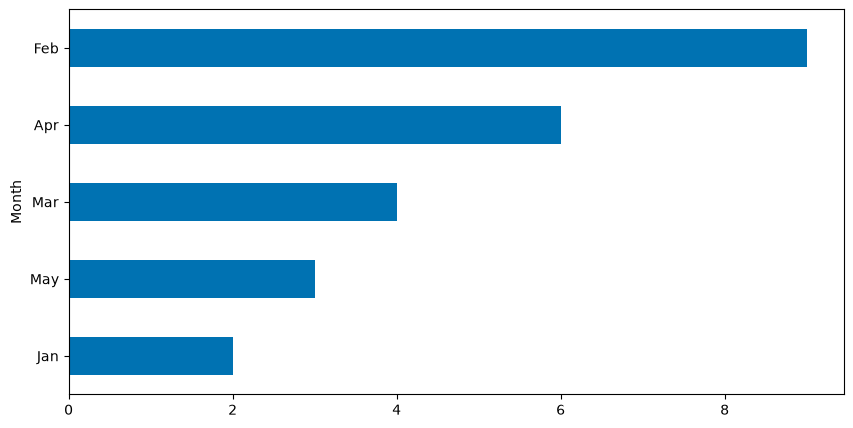

In [29]:
# Create your plot here.
by_month.get('Date').plot(kind='barh'); # SOLUTION

**Question 1.7.** In each row of `artpower`, we are given the `'Latitude'` and `'Longitude'`, which tells us a precise geographical location for each ArtPower event. To see how events are located relative to one another, create a scatter plot with `'Longitude'` on the x-axis and `'Latitude'` on the y-axis for every event in the `artpower` DataFrame. 

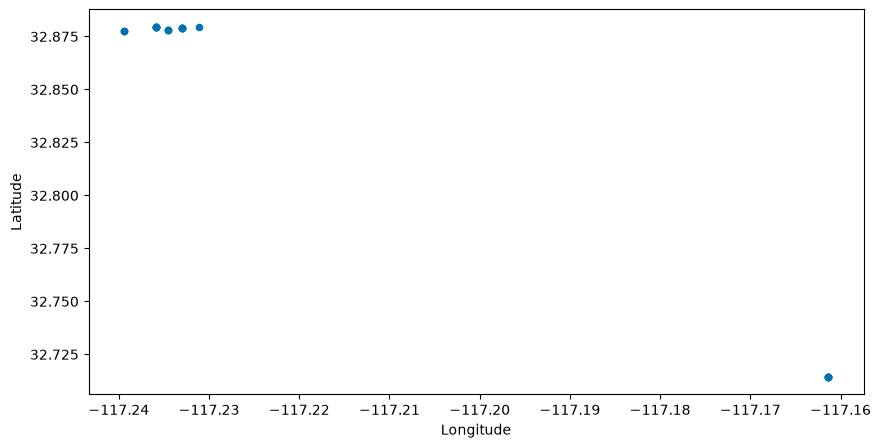

In [30]:
# Create your plot here.
artpower.plot(kind='scatter', x='Longitude', y='Latitude'); # SOLUTION

Your scatter plot shows how the event locations are related to one another geographically, but it's hard to draw much insight from such a basic plot. For example, you might not realize from looking at the plot above that many dots in the upper left corner correspond to events happening on UC San Diego's campus, while the dots in the bottom right correspond to events happening in downtown San Diego. That would be much easier to discover if we could plot these points not just on a scatter plot, but on a map.

Luckily, there's a Python package for that. Run the cell below to import the package `folium`, which supports maps, and to see the ArtPower events on a map we've created using the `'Latitude'` and `'Longitude'` values in `artpower`. You don't need to understand the code that creates the map, but do try zooming in and clicking around on the map that is produced.


In [31]:
import folium
from folium.plugins import MarkerCluster

def create_map():
    my_map = folium.Map(location=[32.8, -117.2], zoom_start=11)
    marker_cluster = MarkerCluster().add_to(my_map)
    for i in np.arange(artpower.shape[0]):
        folium.Marker(
            location=[artpower.get('Latitude').iloc[i], artpower.get('Longitude').iloc[i]],
            tooltip="Click me!",
            popup=artpower.get('Event Name').iloc[i] + ' on ' + artpower.get('Date').iloc[i],
            icon=folium.Icon(icon="star")
        ).add_to(marker_cluster)
    return my_map

create_map()

**Question 1.8.** From exploring the map above, you should see that there are only a few different `'Location'`s where ArtPower events take place. Since the map automatically clusters events at nearby `'Location'`s, you can easily see how many events take place on campus versus off campus. 

In the cell below, write code to extract the number of upcoming ArtPower events that will take place on and off campus, storing your results in `on_campus` and `off_campus`, respectively. Don't just type in the numbers you see in the map above; write code to extract the values from the `artpower` DataFrame. When you're done, make sure that your results agree with what you see in the map. 

You will need to use the fact that the only off-campus `'Location'` for upcoming ArtPower events is `'Balboa Theatre'` in downtown San Diego.

In [32]:
on_campus = artpower[artpower.get('Location')!='Balboa Theatre'].shape[0] # SOLUTION
off_campus = artpower.shape[0] - on_campus # SOLUTION
print("There are", on_campus, "events on campus and", off_campus, "events off campus.")

There are 18 events on campus and 6 events off campus.


In [33]:
import numbers
bool(isinstance(on_campus, numbers.Integral) and isinstance(off_campus, numbers.Integral))

True

In [34]:
bool(on_campus + off_campus == artpower.shape[0])

True

In [35]:
bool(on_campus == 18 and off_campus == 6)

True

## 2. Broadway Bound 🎭

<center><img src='images/hamilton.jpg' width = 400/></center>

The two-part film series *Wicked*, a major box office success, is based on the Broadway musical of the same name. In this problem, we'll analyze other Broadway shows. We've provided a file, `./data/broadway.csv` that contains information about Broadway plays and musicals from 1985 to 2020. The dataset comes from [Kaggle](https://www.kaggle.com/datasets/jessemostipak/broadway-weekly-grosses?select=grosses.csv) and was originally scraped from [Playbill](https://playbill.com/grosses) contains a row for each week for each show on Broadway. For each week and show combination, we have the following pieces of information that we will use to generate insights about the state of musicals over time. 

|Column|Description|
|------|-----------|
|`'Week Ending'`|The week, referenced by the Sunday at the end of the week.|
|`'Show'`|The name of the play or musical.|
|`'Theatre'`|The location or venue at which the show was held.|
|`'Weekly Gross'`|The total revenue generated from ticket sales for that show during that week.|
|`'Seats Sold'`|The total number of seats sold for that show during that week.|
|`'Performances'`|The number of performances of the show held during that week, including "previews" before the official opening.|

In [36]:
# Run this cell to load the dataset.
broadway = pd.read_csv('data/broadway.csv') 
broadway

,Week Ending,Show,Theatre,Weekly Gross,Seats Sold,Performances
0,1985-06-09,42nd Street,St. James Theatre,282368.00,9281,8
1,1985-06-09,A Chorus Line,Sam S. Shubert Theatre,222584.00,8167,8
2,1985-06-09,Aren't We All?,Brooks Atkinson Theatre,249272.00,7386,8
3,1985-06-09,Arms and the Man,Circle in the Square Theatre,95688.00,4586,8
4,1985-06-09,As Is,Lyceum Theatre,61059.00,2938,8
...,...,...,...,...,...,...
47394,2020-03-01,The Phantom of the Opera,Majestic Theatre,639215.93,8856,8
47395,2020-03-01,Tina: The Tina Turner Musical,Lunt-Fontanne Theatre,1320766.00,10004,8
47396,2020-03-01,To Kill A Mockingbird,Sam S. Shubert Theatre,1132278.54,9811,7
47397,2020-03-01,West Side Story,Broadway Theatre,1598947.32,13920,8


**Question 2.1.** Find the name of the show that generated the most revenue during the timespan of our dataset. Assign your answer to `most_revenue_show`. 

In [37]:
most_revenue_show = broadway.groupby('Show').sum().sort_values(by='Weekly Gross', ascending=False).index[0] # SOLUTION
most_revenue_show

'The Lion King'

In [38]:
""" # BEGIN TEST CONFIG
failure_message: "most_revenue_show should be the name of a show"
""" # END TEST CONFIG
bool(most_revenue_show in broadway.get('Show').unique())

True

In [39]:
bool(most_revenue_show == 'The Lion King')

True

**Question 2.2.** Broadway shows come and go, but some stay longer than others. Which show in `broadway` was on Broadway for the greatest number of weeks (not necessarily consecutive)? Assign you answer to `most_weeks_show`.

In [40]:
most_weeks_show = broadway.groupby('Show').count().sort_values('Week Ending', ascending=False).index[0] # SOLUTION
most_weeks_show

'The Phantom of the Opera'

In [41]:
bool(isinstance(most_weeks_show, str))

True

In [42]:
""" # BEGIN TEST CONFIG
failure_message: "most_weeks_show should be the name of a show"
""" # END TEST CONFIG
bool(most_weeks_show in broadway.get('Show').unique())

True

In [43]:
bool(most_weeks_show == 'The Phantom of the Opera')

True

**Question 2.3.** Add a column to `broadway` that contains, for each week and show combination, the average price of a ticket for that show during that week. Call your new column `'AvgTicket'`, and save the resulting DataFrame in the variable `broadway`.

In [44]:
broadway = broadway.assign(AvgTicket = broadway.get('Weekly Gross')/broadway.get('Seats Sold')) # SOLUTION
broadway                    

,Week Ending,Show,Theatre,Weekly Gross,Seats Sold,Performances,AvgTicket
0,1985-06-09,42nd Street,St. James Theatre,282368.00,9281,8,30.424308
1,1985-06-09,A Chorus Line,Sam S. Shubert Theatre,222584.00,8167,8,27.254071
2,1985-06-09,Aren't We All?,Brooks Atkinson Theatre,249272.00,7386,8,33.749255
3,1985-06-09,Arms and the Man,Circle in the Square Theatre,95688.00,4586,8,20.865242
4,1985-06-09,As Is,Lyceum Theatre,61059.00,2938,8,20.782505
...,...,...,...,...,...,...,...
47394,2020-03-01,The Phantom of the Opera,Majestic Theatre,639215.93,8856,8,72.178854
47395,2020-03-01,Tina: The Tina Turner Musical,Lunt-Fontanne Theatre,1320766.00,10004,8,132.023790
47396,2020-03-01,To Kill A Mockingbird,Sam S. Shubert Theatre,1132278.54,9811,7,115.409086
47397,2020-03-01,West Side Story,Broadway Theatre,1598947.32,13920,8,114.866905


In [45]:
bool(broadway.shape[1] == 7)

True

In [46]:
""" # BEGIN TEST CONFIG
failure_message: "Check capitalization and spelling of your column name."
""" # END TEST CONFIG
bool('AvgTicket' in broadway.columns)

True

In [47]:
bool(np.all(broadway.get('AvgTicket') == broadway.get('Weekly Gross')/broadway.get('Seats Sold')))

True

**Question 2.4.** The musical *Wicked* has been at the Gershwin Theatre continuously since its opening in 2003. Create a line plot that displays how the average weekly ticket price for *Wicked* has changed over time.

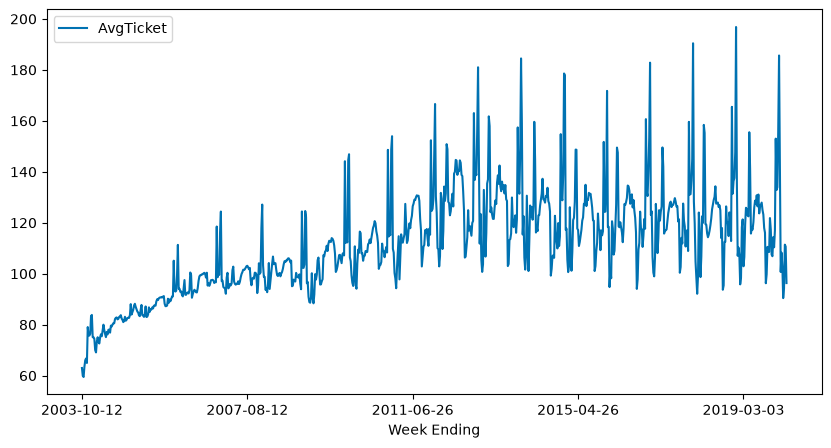

In [48]:
# Create your line plot here.
(broadway[broadway.get('Show') == 'Wicked'].get(['Week Ending', 'AvgTicket']).plot(kind='line', x='Week Ending', y='AvgTicket')); # SOLUTION

It looks like *Wicked* ticket prices fluctuate a lot throughout each year, which is referred to as *seasonal variation*. Most likely, this phenomenon is not particular to *Wicked* but exists to some degree for all Broadway shows. Let's try to find out what time of year Broadway tickets are most expensive. 

**Question 2.5.** Create a new DataFrame called `with_month` that has all the data in `broadway`, plus a column called `'Month'`. `'Month'` should contain strings with two characters (e.g. `'04'` for April) corresponding to the dates in the `'Week Ending'` column. 

***Hint:*** Use the function you wrote in Question 1.4 to extract the month. Even though dates are written differently in this problem than in the last problem, the process of pulling out the month from a full date is exactly the same!

In [49]:
with_month = broadway.assign(Month=broadway.get('Week Ending').apply(month_of_year)) # SOLUTION
with_month

,Week Ending,Show,Theatre,Weekly Gross,Seats Sold,Performances,AvgTicket,Month
0,1985-06-09,42nd Street,St. James Theatre,282368.00,9281,8,30.424308,06
1,1985-06-09,A Chorus Line,Sam S. Shubert Theatre,222584.00,8167,8,27.254071,06
2,1985-06-09,Aren't We All?,Brooks Atkinson Theatre,249272.00,7386,8,33.749255,06
3,1985-06-09,Arms and the Man,Circle in the Square Theatre,95688.00,4586,8,20.865242,06
4,1985-06-09,As Is,Lyceum Theatre,61059.00,2938,8,20.782505,06
...,...,...,...,...,...,...,...,...
47394,2020-03-01,The Phantom of the Opera,Majestic Theatre,639215.93,8856,8,72.178854,03
47395,2020-03-01,Tina: The Tina Turner Musical,Lunt-Fontanne Theatre,1320766.00,10004,8,132.023790,03
47396,2020-03-01,To Kill A Mockingbird,Sam S. Shubert Theatre,1132278.54,9811,7,115.409086,03
47397,2020-03-01,West Side Story,Broadway Theatre,1598947.32,13920,8,114.866905,03


In [50]:
bool(broadway.shape[1] == 7 and with_month.shape[1] == 8 and 'Month' in with_month.columns)

True

In [51]:
bool(np.isclose(with_month.get('Month').values.astype(int).mean(), 6.5377117660710145))

True

**Question 2.6.** Create a line plot showing the mean value of `'AvgTicket'` for each month of the year, to see the seasonal variation. Then, assign `most_expensive` to the month of the year (again, as a string like `'04'`) where ticket prices tend to be the most expensive. Extract this month using Python code, but verify visually that it matches up with what your line plot shows.

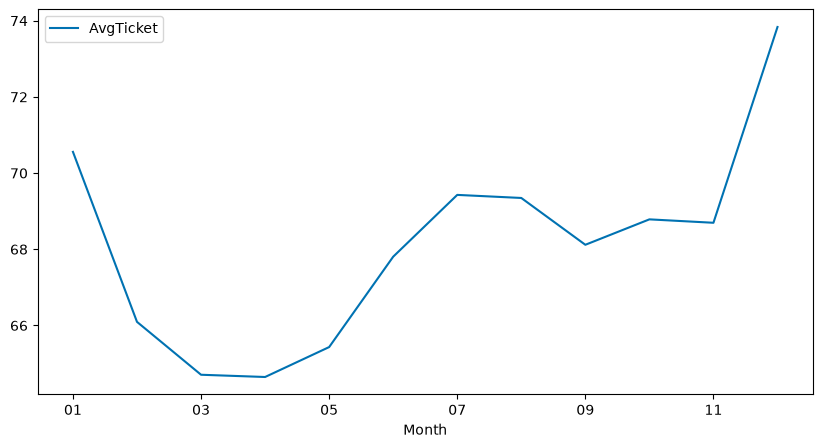

In [52]:
# Create your line plot here.
with_month.get(['Month', 'AvgTicket']).groupby('Month').mean().plot(kind='line', y='AvgTicket'); # SOLUTION 

In [53]:
most_expensive = with_month.get(['Month', 'AvgTicket']).groupby('Month').mean().sort_values(by='AvgTicket', ascending=False).index[0] # SOLUTION
most_expensive 

'12'

In [54]:
bool(most_expensive in ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12',]) 

True

In [55]:
bool(most_expensive == '12')

True

**Question 2.7.** Which Broadway theatres have hosted the most performances? To answer this question, create a DataFrame named `theatre_proportions` indexed by `Theatre`, with one column `'Proportion'`. The `'Proportion'` column should contain, for each theatre, the proportion of performances in the dataset that were held in that theatre. Remember that each row of our dataset corresponds to multiple performances! Order the rows of `theatre_proportions` in descending order of `'Proportion'`. 

In [56]:
theatre_counts = broadway.groupby('Theatre').sum() # SOLUTION NO PROMPT
performances =  theatre_counts.get('Performances') # SOLUTION NO PROMPT
theatre_proportions = theatre_counts.assign(Proportion=performances / performances.sum()).get(['Proportion']) # SOLUTION NO PROMPT
theatre_proportions = theatre_proportions.sort_values(by='Proportion', ascending=False) # SOLUTION 
theatre_proportions

,Proportion
Theatre,
Broadhurst Theatre,0.038552
Minskoff Theatre,0.037367
Majestic Theatre,0.036009
Imperial Theatre,0.035565
Ambassador Theatre,0.034342
Gershwin Theatre,0.032768
Eugene O'Neill Theatre,0.031561
St. James Theatre,0.031206
Lunt-Fontanne Theatre,0.031198


In [57]:
bool(isinstance(theatre_proportions, pd.DataFrame) and set(theatre_proportions.columns) == {'Proportion'})

True

In [58]:
bool(np.isclose(theatre_proportions.get('Proportion').sum(), 1))

True

In [59]:
""" # BEGIN TEST CONFIG
failure_message: "Tests that the DataFrame is sorted."
""" # END TEST CONFIG
bool(theatre_proportions.index[1] == 'Minskoff Theatre')

True

In [60]:
bool(np.isclose(theatre_proportions.get('Proportion').loc['Gershwin Theatre'], 0.03276820328517201))

True

**Question 2.8.** Broadway shows tend to bring in a lot of money each week! With multiple performances, packed theatres, and high ticket prices, the revenue stream is flowing! Let's explore how much money was brought in each week by the show *Hamilton*,  a popular award-winning musical that debuted on Broadway in 2015. Plot a density histogram that shows the distribution of `'Weekly Gross'` for *Hamilton* over the period between its debut and the end of data collection. Use bins with a width of a quarter of a million dollars, and make sure that all the data from *Hamilton* is included within your bins.

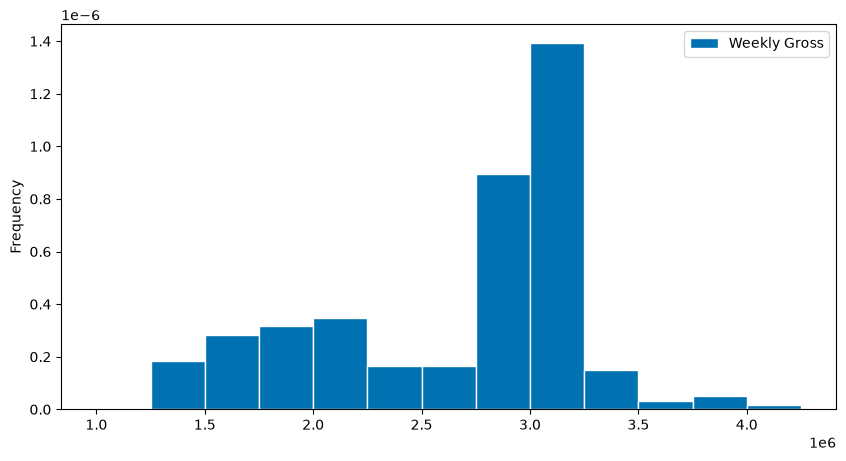

In [61]:
# Create your histogram here.
hamilton = broadway[(broadway.get('Show') == 'Hamilton')] # SOLUTION NO PROMPT
hamilton.plot(kind='hist', y='Weekly Gross', density=True, ec='w', bins = np.arange(1, 4.5, 0.25) * 1000000); # SOLUTION

**Question 2.9.** Without writing any code, can you estimate the proportion of weeks for which *Hamilton* earned between \\$3,000,000 (inclusive) and \\$3,250,000 (exclusive)? Assign your answer to `prop_between` as a float between 0 and 1.

In [62]:
prop_between = 0.35 # SOLUTION
prop_between

0.35

In [63]:
bool(isinstance(prop_between, float))

True

In [64]:
bool(prop_between >= 0 and prop_between <= 1)

True

In [65]:
bool(prop_between >= 0.33 and prop_between <= 0.37)

True

**Question 2.10.** Broadway shows often have interesting and memorable names that reflect their themes, characters, or settings. From classics like *The Phantom of the Opera* to modern hits like *Hamilton*, these names capture the imagination and hint at the unique stories waiting to be told on stage. How often do Broadway shows get one-word names? Assign `one_word` to the proportion of Broadway show names that are only one word. Remember, each show appears multiple times in our DataFrame!

***Note:*** Some shows are made up of numbers only, which are not really "words" in the conventional sense. We'll consider words to be chunks of text separated by spaces, so for example, the show `"1776"` should count as having one word.

In [66]:
# BEGIN SOLUTION NO PROMPT
def has_one_word(show):
    '''No spaces means the show has one word'''
    return not " " in show
# END SOLUTION 
one_word = broadway.groupby('Show').count().reset_index().get('Show').apply(has_one_word).mean() # SOLUTION
one_word

0.1806797853309481

In [67]:
bool(isinstance(one_word, float))

True

In [68]:
bool(np.isclose(one_word, 0.1806797853309481))

True

## 3. Final Stretch 🧘‍♀️

Suppose we have a DataFrame named `data` with two numerical columns, `'x'` and `'y'`. Consider the following scatter plot, which was generated by calling `data.plot(kind='scatter', x='x', y='y')`:

<img src='images/q3_scatter.png' width=400/>

Now consider these two histograms:

<center>
    <table><tr>
        <td><center><b>Histogram A</b><br> <img src='images/q3_hist_one.png' width=400></center> </td>
        <td><center><b>Histogram B</b><br> <img src='images/q3_hist_two.png' width=400></center> </td>
    </tr></table>
</center>

**Question 3.1.** Which of the following lines of code generated Histogram A? Assign either `1`, `2`, `3`, or `4` to `which_code`.

 1. `data.plot(kind='hist', density=False, y='x')`
 2. `data.plot(kind='hist', density=False, y='y')` 
 3. `data.plot(kind='hist', density=True, y='x')`
 4. `data.plot(kind='hist', density=True, y='y')`

In [69]:
which_code = 4 # SOLUTION

In [70]:
bool(which_code in {1, 2, 3, 4})

True

In [71]:
bool(which_code == 4)

True

**Question 3.2.** Suppose we run this block of code:

```py
new_data = pd.DataFrame().assign(
    x = data.get('x') / 5,
    y = data.get('y')
)
```
    
We then run 

`new_data.plot(kind='hist', density=True, y='x')`.

How will this histogram look compared to the histogram created by 

`data.plot(kind='hist', density=True, y='x')`, 

assuming both histograms are drawn on the same axes? Assign `histogram_difference` to either 1, 2, 3, or 4, corresponding to your choice.

1. The `new_data` histogram will be wider and taller than the `data` histogram.
2. The `new_data` histogram will be wider and shorter than the `data` histogram.
3. The `new_data` histogram will be narrower and taller than the `data` histogram.
4. The `new_data` histogram will be narrower and shorter than the `data` histogram.

_*Hint*_: Look at the end of [Lecture 7](https://dsc10.com/resources/lectures/lec07/lec07.html#Plotting-overlaid-histograms) for an example of two histograms drawn on the same axes.

In [72]:
histogram_difference = 3 # SOLUTION

In [73]:
bool(histogram_difference in {1, 2, 3, 4})

True

In [74]:
bool(histogram_difference == 3)

True

**Question 3.3.** Below, we show Histogram B again.

<img src="images/q3_hist_two.png" width=400/>

What **percent** of values in Histogram B are between -4 (inclusive) and -2 (exclusive)? While we cannot answer this question exactly since we do not know where the bins start and end, we can still approximate the answer. Assign the variable `percent_between` to a number 1 through 5, corresponding to the closest answer.

1. 10% 
2. 13% 
3. 27%
4. 35%
5. 48%

In [75]:
percent_between = 3 # SOLUTION

In [76]:
bool(percent_between in {1, 2, 3, 4, 5})

True

In [77]:
bool(percent_between == 3)

True

In [78]:
# For your convenience, you can run this cell to run all the tests at once!
grader.check_all()